# Notebook 01: Korelacijske mreže i mrežne mjere

**Projekt:** Financijske mreže na ZSE (CROBEX, 2004–2026)
**Teme:** Korelacijske matrice, P-prag filtriranje, mjere mrežne topologije

## Kontekst

Financijske mreže konstruiramo iz **matrice korelacija** dionica.
Svaka dionica je čvor; brid postoji samo ako je korelacija statistički značajna
(P-prag pristup, Xu et al. 2017).

Analiziramo **10 mrežnih mjera** koje opisuju strukturu tržišta u svakom vremenskom prozoru:

| Mjera | Opis |
|-------|------|
| M1 LCC | Frakcija dionica u najvećoj komponenti NG mreže |
| M2 APL | Prosječna duljina najkraćeg puta |
| M3 MeanDeg | Prosječni stupanj čvora |
| M4 NCom | Broj zajednica (samo u stresnim periodima) |
| M5 Mod | Modularnost (snaga zajednica) |
| M6 AbsRat | Apsorpcijski omjer (sistemski rizik) |
| M7 Close | Prosječna centralnost blizine |
| M8 EigMn | Prosječna eigenvector centralnost |
| M9 EigMx | Maksimalna eigenvector centralnost (PG mreža) |
| M10 PCorr | Prosječna rezidualna korelacija |


In [1]:
# Postavljanje okolisa (automatski detektira Google Colab)
import sys
if "google.colab" in sys.modules:
    import urllib.request, os
    os.makedirs("/content/sample_data", exist_ok=True)
    _base = "https://raw.githubusercontent.com/svlah-sketch/FinNet-teaching/main/sample_data/"
    for _f in ["sample_metrics_W90.csv", "sample_metrics_revision.csv",
               "CROBEX_values.csv", "Revisions.csv"]:
        urllib.request.urlretrieve(_base + _f, f"/content/sample_data/{_f}")
    print("Colab: podaci preuzeti s GitHuba.")
else:
    print("Lokalno pokretanje.")


Colab: podaci preuzeti s GitHuba.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Automatski pronalazi sample_data/ (Colab ili lokalno)
import sys
if "google.colab" in sys.modules:
    DATA_DIR = Path("/content/sample_data")
else:
    for _p in [Path("../sample_data"), Path("sample_data")]:
        if _p.exists() and list(_p.glob("*.csv")):
            DATA_DIR = _p
            break
    else:
        raise FileNotFoundError(
            "sample_data/ nije pronađen. Pokreni prvu celiju notebooka.")
print(f"DATA_DIR: {DATA_DIR.resolve()}")

# Učitaj mrežne mjere (W90 — prozori od 90 dana)
metrics = pd.read_csv(DATA_DIR / "sample_metrics_W90.csv",
                      index_col="window_end", parse_dates=True)

print(f"Oblik podataka: {metrics.shape}")
print(f"Vremenski raspon: {metrics.index.min().date()} do {metrics.index.max().date()}")
print()
print(metrics.head())

DATA_DIR: /content/sample_data
Oblik podataka: (59, 10)
Vremenski raspon: 2005-01-27 do 2026-01-19

              M1_LCC    M2_APL  M3_MeanDeg  M4_NCom  M5_Mod  M6_AbsRat  \
window_end                                                               
2005-01-27  0.318182  2.190476    0.909091      NaN     NaN   0.349594   
2005-06-07  0.259259  2.380952    1.185185      NaN     NaN   0.454550   
2005-10-14  0.269231  2.190476    0.692308      NaN     NaN   0.439604   
2006-02-22  0.354839  3.090909    0.838710     30.0     0.0   0.407459   
2006-07-06  0.552632  3.747619    1.421053     36.0     0.5   0.443885   

            M7_Close  M8_EigMn  M9_EigMx  M10_PCorr  
window_end                                           
2005-01-27  0.181881       NaN  0.634769  -0.019050  
2005-06-07  0.273661       NaN  0.544189  -0.029504  
2005-10-14  0.182976       NaN  0.578347  -0.019830  
2006-02-22  0.141212  0.045622  0.431240  -0.008933  
2006-07-06  0.213185  0.037266  0.451258  -0.008206  


## 1. Deskriptivna statistika mrežnih mjera

In [3]:
desc = metrics.describe().T
desc["% missing"] = metrics.isna().mean() * 100
print(desc[["mean","std","min","max","% missing"]].round(3).to_string())

              mean     std     min     max  % missing
M1_LCC       0.436   0.234   0.105   0.889      0.000
M2_APL       2.634   0.982   1.000   4.588      0.000
M3_MeanDeg   1.153   0.554   0.286   2.444      0.000
M4_NCom     29.875  10.912  12.000  46.000     59.322
M5_Mod       0.193   0.282   0.000   0.667     59.322
M6_AbsRat    0.441   0.104   0.273   0.757      0.000
M7_Close     0.205   0.095   0.041   0.384      0.000
M8_EigMn     0.055   0.024   0.029   0.109     61.017
M9_EigMx     0.560   0.089   0.408   0.707      1.695
M10_PCorr   -0.013   0.015  -0.071   0.022      0.000


**Što čitati u tablici:** `mean` i `std` govore o tipičnim vrijednostima kroz sve prozore. `% missing` je ključan: M4, M5, M8 imaju ~50–70% missing — to su kondicionalne mjere aktivne samo u stresnim periodima (NG-0.001 neprazna). M1, M2, M3, M6, M7, M9, M10 imaju 0% missing — uvijek dostupne.

> Visoka standardna devijacija kod M1 i M3 znači da te mjere jako variraju između mirnih i kriznih prozora — upravo to ih čini korisnima za detekciju stresa.

## 2. Vremenska serija odabranih mjera

Vizualiziramo M1 (LCC frakcija), M3 (prosječni stupanj) i M6 (apsorpcijski omjer).
Označeni su periodi tri financijske krize.


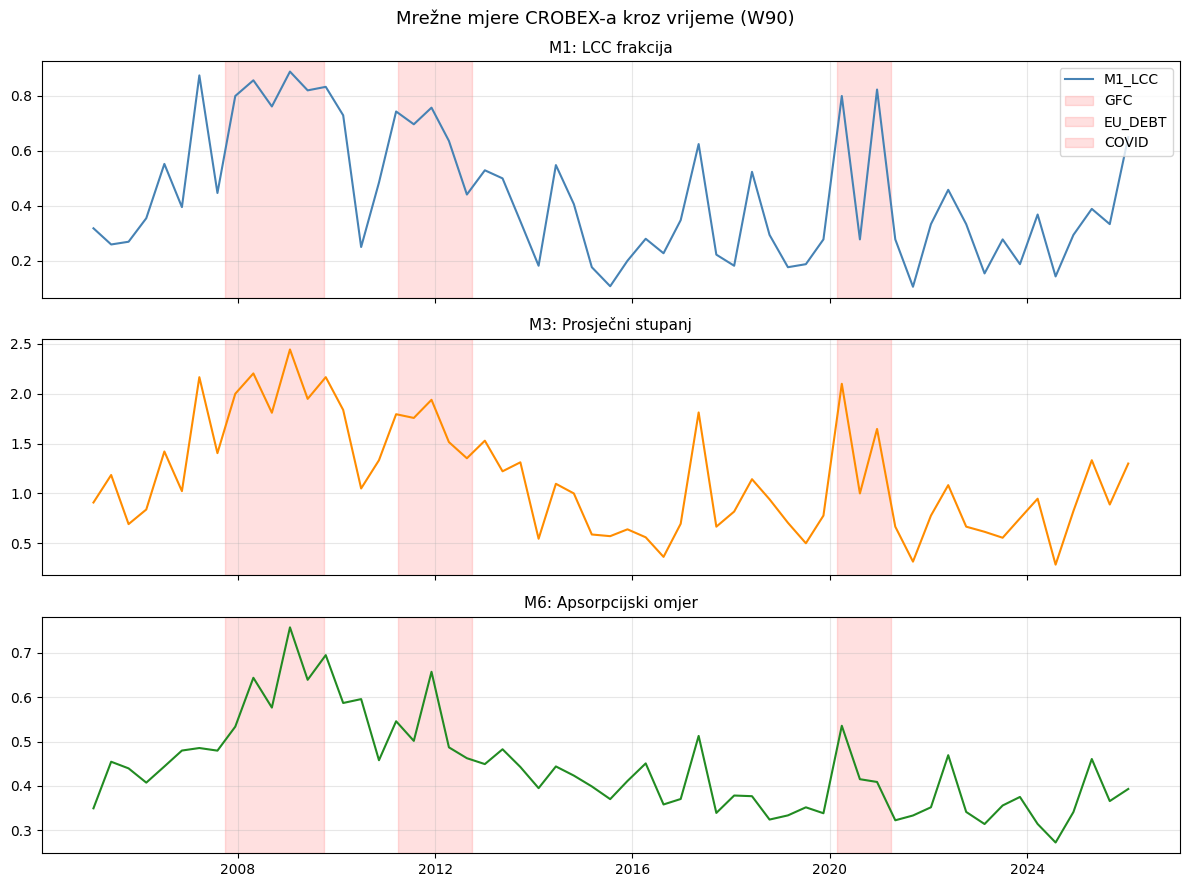

In [4]:
CRISES = {
    "GFC":     ("2007-10-01", "2009-09-30"),
    "EU_DEBT": ("2011-04-01", "2012-09-30"),
    "COVID":   ("2020-02-20", "2021-03-31"),
}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
cols = ["M1_LCC", "M3_MeanDeg", "M6_AbsRat"]
titles = ["M1: LCC frakcija", "M3: Prosječni stupanj", "M6: Apsorpcijski omjer"]
colors = ["steelblue", "darkorange", "forestgreen"]

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.plot(metrics.index, metrics[col], color=color, lw=1.5, label=col)
    for name, (start, end) in CRISES.items():
        ax.axvspan(start, end, alpha=0.12, color="red", label=name if col == cols[0] else "")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[0].legend(loc="upper right")
fig.suptitle("Mrežne mjere CROBEX-a kroz vrijeme (W90)", fontsize=13)
plt.tight_layout()
plt.savefig("notebook01_figure.png", dpi=120, bbox_inches="tight")
plt.show()

**Što vidimo na vremenskom grafu:** Tri sjenčana pojasa označavaju GFC (2008–09), EU dug (2011–12) i COVID (2020–21). Sve tri mjere pokazuju skokove za vrijeme kriza.

- **M1 (LCC frakcija):** dramatičan rast u GFC — negativna mreža postaje gusta i gotovo cijelo tržište u jednoj komponenti
- **M3 (prosječni stupanj):** sličan obrazac, ali reagira brže (mjeri gustoću direktno)
- **M6 (apsorpcijski omjer):** sporiji, konzistentni rast — mjeri dugoročnu koncentraciju sistemskog rizika, ne samo trenutni šok

> Pitanje za razmisliti: zašto M6 ne vraća na bazičnu razinu jednako brzo kao M1 i M3?

## 3. Korelacijska matrica mjera

Koliko su mjere međusobno korelirane? Visoka korelacija sugerira da mjere
hvate iste aspekte tržišne strukture.


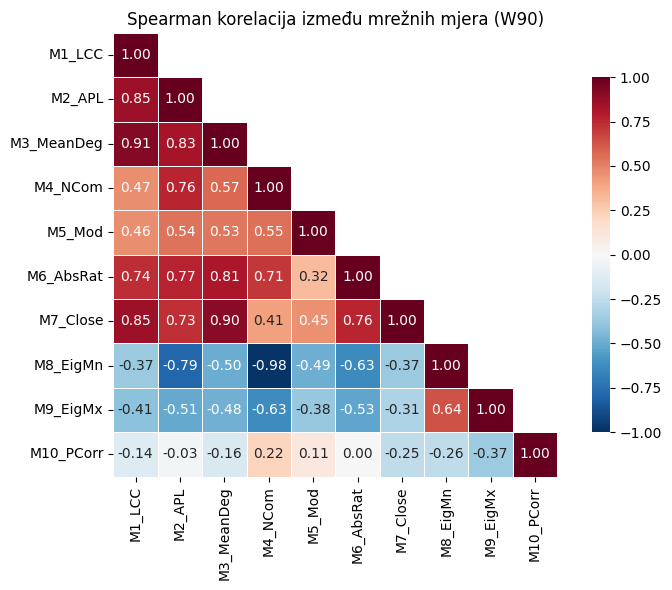

In [5]:
corr = metrics.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Spearman korelacija između mrežnih mjera (W90)")
plt.tight_layout()
plt.savefig("notebook01_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

**Što vidimo na heatmapi:** Svaka ćelija = Spearman korelacija para mjera kroz sve prozore. Crvena = pozitivna, plava = negativna.

- **M1, M2, M3, M7** visoko korelirani međusobno — sve mjere gustoće/povezanosti NG-0.05 mreže; hvata iste aspekte tržišnog stresa
- **M6** umjereno koreliran s M1–M3 — apsorpcijski omjer gradi iz drugog izvora (kovarijacijska matrica, ne P-prag mreža) ali hvata sličan signal
- **M4, M8** slabije korelirani s ostalima jer su kondicionalni — uzorak im je samo stresni prozori
- **M9** (PG mreža) može imati suprotan predznak — mjeri hub-ove u *pozitivnoj* mreži

> Visoka međukorelacija unutar grupe M1–M3–M7 znači da nije nužno koristiti sve tri — ali svaka nosi i jedinstven signal koji opravdava uključivanje.

## 4. Razdioba mjera: krize vs. mirna razdoblja

Uspoređujemo raspodjele M1 (LCC) i M3 (stupanj) za krizna i mirna razdoblja.
Vizualni pregled — formalni statistički testovi su u Notebooku 02.


Kriznih prozora: 12 / 59


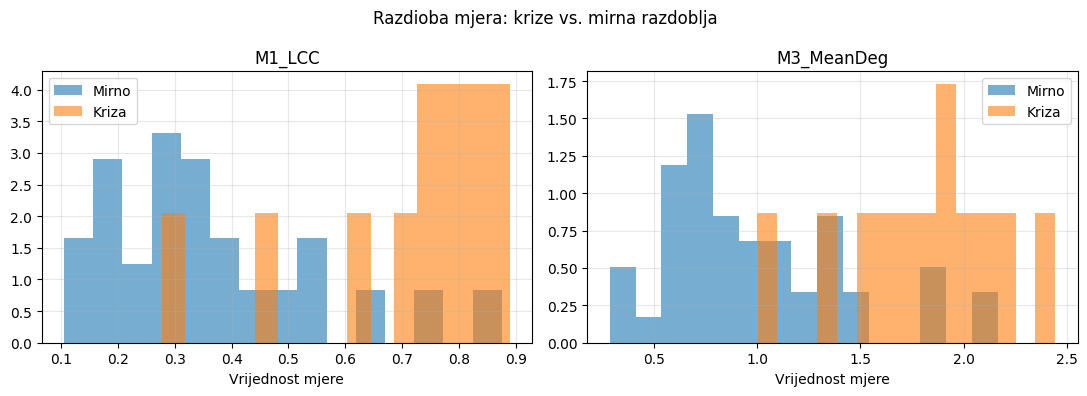

In [6]:
revs_dates = pd.read_csv(DATA_DIR / "Revisions.csv", sep=";", encoding="cp1250")
revs_dates["start_date"] = pd.to_datetime(revs_dates["start_date"], dayfirst=True)
revs_dates["end_date"]   = pd.to_datetime(revs_dates["end_date"],   dayfirst=True)

def is_crisis(date):
    for start, end in CRISES.values():
        if pd.Timestamp(start) <= date <= pd.Timestamp(end):
            return True
    return False

metrics["kriza"] = metrics.index.map(is_crisis)
print(f"Kriznih prozora: {metrics['kriza'].sum()} / {len(metrics)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["M1_LCC", "M3_MeanDeg"]):
    for label, group in metrics.groupby("kriza")[col]:
        ax.hist(group.dropna(), bins=15, alpha=0.6,
                label="Kriza" if label else "Mirno", density=True)
    ax.set_title(col)
    ax.set_xlabel("Vrijednost mjere")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("Razdioba mjera: krize vs. mirna razdoblja")
plt.tight_layout()
plt.show()
metrics.drop(columns=["kriza"], inplace=True)


> **Napomena o definiciji kriznih prozora:** Prozor je označen kao krizni ako njegov  pada unutar kriznog razdoblja. Ovo je pojednostavljivanje — prozor koji završi dan-dva izvan krize može biti pretežno krizni. Za istraživačke svrhe preporučuje se provjera robusnosti s definicijom temeljenom na preklapanju prozora s kriznim periodom.


**Što vidimo na histogramima:** Svaki histogram prikazuje raspodjelu mjere za krizne (narančasto) i mirne (plavo) prozore.

Ako se distribucije **malo preklapaju** i narančasta je **pomaknuta desno** → mjera dobro razlikuje krize od mirnih perioda.

Ako se distribucije **jako preklapaju** → mjera sama nije dovoljna za klasifikaciju.

> Ovo je vizualni pregled. Formalni statistički test (Mann-Whitney) koji kvantificira tu razliku vidjet ćete u Notebooku 02.

---

## Vježbe

**1.** Koji par mjera ima najveću apsolutnu Spearman korelaciju? Zašto biste to
   očekivali s obzirom na njihove definicije?

**2.** Dodajte u vremenski graf M9 (EigMx — PG mreža). Ima li suprotan trend od M1?
   Što to govori o ulozi "hub" dionica u mirnim i kriznim periodima?

**3.** Koliko prozora pripada svakoj krizi (GFC, EU_DEBT, COVID)?
   Koristite `metrics.index` i datume kriza iz rječnika `CRISES`.

**4.** (Napredni) M4 i M8 imaju puno NaN vrijednosti. Pogledajte `% missing` iz
   deskriptivne statistike. Zašto bi te mjere bile dostupne samo u *nekim* prozorima?
   (Hint: NG-0.001 prag)
